# Trabalho/Atividade 5 em grupo de Regressão

## Integrantes do Grupo:
- Matheus Brito
- Marcella Cobra
- Marcelo Huang

---

Enunciado: "*Encontre um conjunto de dados com, no minimo, 8 covariaveis. Ajuste um modelo de regressão nos seus dados. Use todas as etapas de análise. Escreva os resultados em um Relatorio em PDF. Prepare uma apresentação do seu Relatorio.*"

---

## Conjunto de dados escolhido: 

Resistência à compressão do Concreto  vs. Idade + Componentes (disponível em [UC Irvine: Concrete Compressive Strength](https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength))

## Etapa 0:  Contextualizando

Nesta atividade, será realizada uma análise de um conjunto de dados dito na sala de aula, usando um modelo de regressão linear $Y = X\beta + \varepsilon$.


A partir desses dados, serão conduzidos: Diagnóstico/Análise de resíduos; Detecção de outliers e pontos influentes; Testes estatísticas; e validação do modelo.

Estamos interessados em como os componentes e a idade impacta na resistência à compressão do concreto

O conjunto de dados original é composto por 8 covariáveis e 1 variável resposta:

* $X_1$: Cimento (quantitativa - kg/$m^3$)
* $X_2$: Escória (quantitativa - kg/$m^3$)
* $X_3$: Cinza Volante (quantitativa - kg/$m^3$)
* $X_4$: Água (quantitativa - kg/$m^3$)
* $X_5$: Superplastificante (quantitativa - kg/$m^3$)
* $X_6$: Agregado Graudo (quantitativa - kg/$m^3$)
* $X_7$: Agregado Miudo (quantitativa - kg/$m^3$)
* $X_8$: Idade = o tempo decorrido desde o momento em que a água entra em contato com o cimento (quantitativa - dia)
* $Y$: Resistência a compressão (quantitativa - MPa)


---

Considerando a natureza das covariáveis, é conveniente considerar as seguintes transformações e interações das covariáveis:

* $X_9$: $\frac{Agua}{Cimento}$ =  $\frac{X_4}{X_1}$
* $X_10$: $\frac{Cimento}{Idade}$ =  $\frac{X_1}{X_8}$
* $X_11$: log(Idade) = log($X_8$)
* $X_12$: $log(Idade)^2 = log(X_8)^2$

In [1]:
library(readxl)
library(lmtest)
library(MASS)      
library(car)        
library(nortest)

### função que automatiza os testes
diagnostico <- function(mod, nome = "Modelo", dados_val, resp_val_orig,
                        transf = c("log", "sqrt", "nenhuma")) {
  transf <- match.arg(transf)
  cat("\n", rep("=", 60), "\n", sep = "")
  cat(" DIAGNÓSTICO:", nome, "\n")
  cat(rep("=", 60), "\n", sep = "")

  res  <- residuals(mod)
  ajus <- fitted(mod)
  n    <- length(res)
  p    <- length(coef(mod))

  # 6a. Normalidade
  sw  <- shapiro.test(res)
  ad  <- ad.test(res)
  cat("\n[Normalidade]\n")
  cat("  Shapiro-Wilk   p =", round(sw$p.value, 4),
      ifelse(sw$p.value > 0.05, "✔ OK", "✘ FALHA"), "\n")
  cat("  Anderson-Darling p =", round(ad$p.value, 4),
      ifelse(ad$p.value > 0.05, "✔ OK", "✘ FALHA"), "\n")

  # 6b. Homocedasticidade
  bp  <- bptest(mod)
  ncv <- ncvTest(mod)
  cat("\n[Homocedasticidade]\n")
  cat("  Breusch-Pagan  p =", round(bp$p.value, 4),
      ifelse(bp$p.value > 0.05, "✔ OK", "✘ FALHA"), "\n")
  cat("  NCV Test       p =", round(ncv$p, 4),
      ifelse(ncv$p > 0.05, "✔ OK", "✘ FALHA"), "\n")

  # 6c. Autocorrelação
  dw <- dwtest(mod)
  cat("\n[Autocorrelação]\n")
  cat("  Durbin-Watson  p =", round(dw$p.value, 4),
      ifelse(dw$p.value > 0.05, "✔ OK", "✘ FALHA"), "\n")

  # 6d. Multicolinearidade
  vifs <- vif(mod)
  cat("\n[VIF — Multicolinearidade]\n")
  print(round(vifs, 2))
  if (any(vifs > 10)) cat("  ⚠ VIF > 10 em algum preditor\n")
  else cat("  ✔ Todos VIF ≤ 10\n")

  # 6e. R² ajustado
  s <- summary(mod)
  cat("\n[Ajuste no treino]\n")
  cat("  R² ajustado =", round(s$adj.r.squared, 4), "\n")

  # 6f. MAPE na validação
  pred_transf <- predict(mod, newdata = dados_val)
  if (transf == "log") {
    pred_orig <- exp(pred_transf)
  } else if (transf == "sqrt") {
    pred_orig <- pred_transf^2
  } else {
    pred_orig <- pred_transf
  }
  mape <- mean(abs((resp_val_orig - pred_orig) / resp_val_orig)) * 100
  cat("\n[Validação — MAPE]\n")
  cat("  MAPE =", round(mape, 2), "%",
      ifelse(mape < 15, "✔ META ATINGIDA (<15%)", "✘ Acima de 15%"), "\n")

  invisible(list(shapiro = sw, ad = ad, bp = bp, dw = dw,
                 vif = vifs, mape = mape, r2adj = s$adj.r.squared))
}

preparar <- function(df) {
  df$sqrtIdade    <- sqrt(df$Idade)
  df$logIdade    <- log(df$Idade)
  df$logCimento   <- log(df$Cimento + 1)
  df$logCinza     <- log(df$CinzaVolante + 1)  # zeros possíveis → +1
  df$logSP        <- log(df$Superplastificante + 1)
  df$razaoAC      <- df$Agua / df$Cimento
  df$CimXIdade    <- df$Cimento * df$Idade  # interação
  df$CimXIdade2    <- (df$Cimento * df$Idade)^2  # interação
  df$sqrtResist   <- sqrt(df$Resistencia)       # alternativa
  df
}


Carregando pacotes exigidos: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Carregando pacotes exigidos: carData



In [2]:
dados_brutos <- read_excel("Concrete_Data.xls")
colnames(dados_brutos) <- c("Cimento","Escoria","CinzaVolante","Agua",
                            "Superplastificante","AgregadoGraudo",
                            "AgregadoMiudo","Idade","Resistencia")

set.seed(20260521)

n_total  <- nrow(dados_brutos)
n_treino <- round(0.70 * n_total)
idx_treino      <- sample(1:n_total, size = n_treino)
dados_treino    <- dados_brutos[ idx_treino, ]
dados_validacao <- dados_brutos[-idx_treino, ]
cat("\nTreino:", nrow(dados_treino), "| Validação:", nrow(dados_validacao), "\n")     

treino    <- preparar(dados_treino)
validacao <- preparar(dados_validacao)




Treino: 721 | Validação: 309 


In [3]:
modL <- lm(sqrtResist ~ Cimento + Escoria + CinzaVolante + Agua + 
          Superplastificante + Idade + AgregadoGraudo + AgregadoMiudo + 
          logIdade + CimXIdade,
          data = treino )

corrplot 0.92 loaded



[1] "Matriz de Correlação:"


,Cimento,Escoria,CinzaVolante,Agua,Superplastificante,AgregadoGraudo,AgregadoMiudo,Idade,logIdade,CimXIdade
Cimento,1.00,-0.27,-0.40,-0.06,0.05,-0.13,-0.23,0.10,0.02,0.31
Escoria,-0.27,1.00,-0.31,0.07,0.06,-0.26,-0.28,-0.04,0.00,-0.10
CinzaVolante,-0.40,-0.31,1.00,-0.24,0.40,-0.03,0.05,-0.16,-0.03,-0.22
Agua,-0.06,0.07,-0.24,1.00,-0.65,-0.17,-0.44,0.28,0.17,0.26
Superplastificante,0.05,0.06,0.40,-0.65,1.00,-0.28,0.23,-0.18,-0.01,-0.16
AgregadoGraudo,-0.13,-0.26,-0.03,-0.17,-0.28,1.00,-0.18,-0.01,-0.06,-0.02
AgregadoMiudo,-0.23,-0.28,0.05,-0.44,0.23,-0.18,1.00,-0.16,-0.11,-0.23
Idade,0.10,-0.04,-0.16,0.28,-0.18,-0.01,-0.16,1.00,0.77,0.94
logIdade,0.02,0.00,-0.03,0.17,-0.01,-0.06,-0.11,0.77,1.00,0.69
CimXIdade,0.31,-0.10,-0.22,0.26,-0.16,-0.02,-0.23,0.94,0.69,1.00


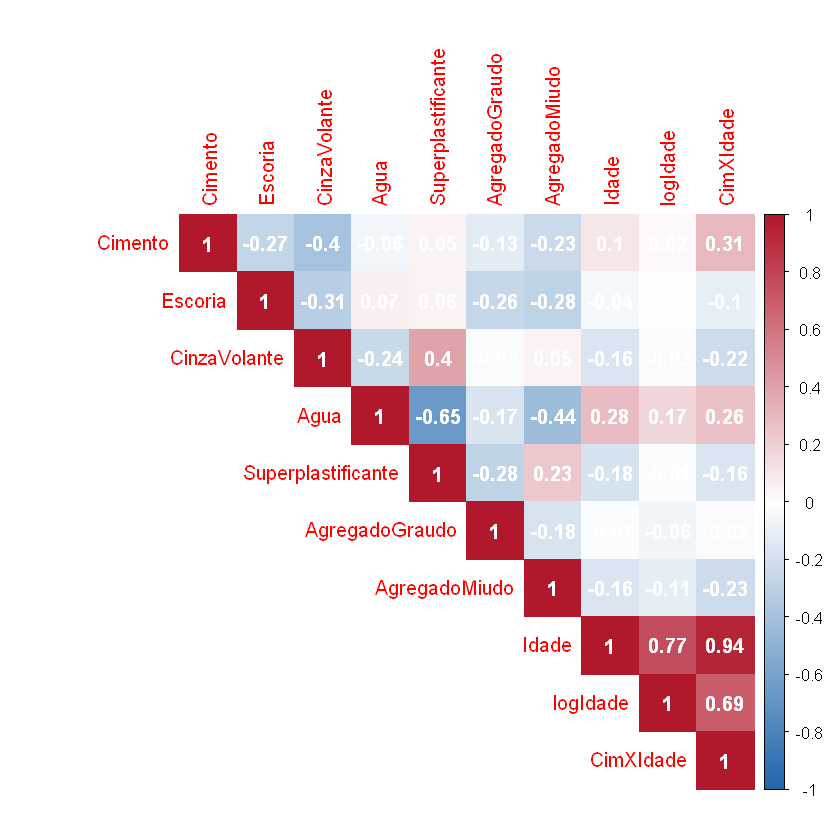

In [4]:
# Matriz de correlação (dados brutos)
library(corrplot)
vars_explicativas <- treino[, c("Cimento", "Escoria", "CinzaVolante", "Agua",
                                      "Superplastificante", "AgregadoGraudo",
                                      "AgregadoMiudo", "Idade", "logIdade", "CimXIdade")]

cor_matrix <- cor(vars_explicativas)
print("Matriz de Correlação:")
round(cor_matrix, 2)

# Visualizar matriz de correlação
corrplot(cor_matrix, 
         method = "color",
         type = "upper",
         addCoef.col = "white",
         col = colorRampPalette(c("#2166AC", "white", "#B2182B"))(200))

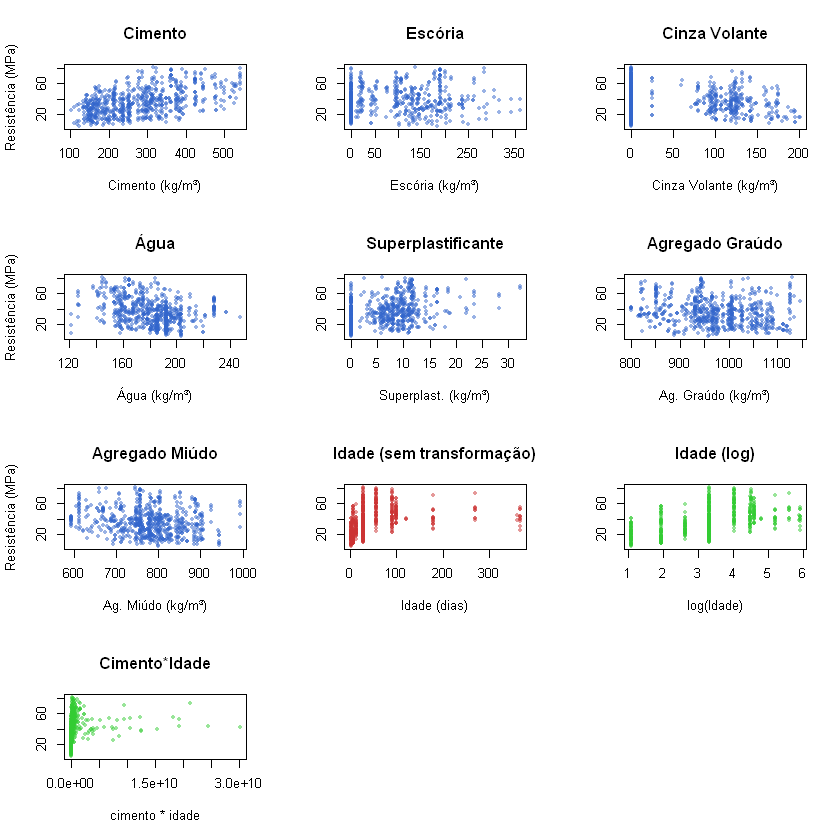

In [5]:
par(mfrow = c(4, 3))
plot(dados_treino$Cimento, dados_treino$Resistencia,
     main = "Cimento", xlab = "Cimento (kg/m³)", ylab = "Resistência (MPa)",
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.5), cex = 0.7)

plot(dados_treino$Escoria, dados_treino$Resistencia,
     main = "Escória", xlab = "Escória (kg/m³)", ylab = "",
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.5), cex = 0.7)

plot(dados_treino$CinzaVolante, dados_treino$Resistencia,
     main = "Cinza Volante", xlab = "Cinza Volante (kg/m³)", ylab = "",
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.5), cex = 0.7)

plot(dados_treino$Agua, dados_treino$Resistencia,
     main = "Água", xlab = "Água (kg/m³)", ylab = "Resistência (MPa)",
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.5), cex = 0.7)

plot(dados_treino$Superplastificante, dados_treino$Resistencia,
     main = "Superplastificante", xlab = "Superplast. (kg/m³)", ylab = "",
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.5), cex = 0.7)

plot(dados_treino$AgregadoGraudo, dados_treino$Resistencia,
     main = "Agregado Graúdo", xlab = "Ag. Graúdo (kg/m³)", ylab = "",
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.5), cex = 0.7)

plot(dados_treino$AgregadoMiudo, dados_treino$Resistencia,
     main = "Agregado Miúdo", xlab = "Ag. Miúdo (kg/m³)", ylab = "Resistência (MPa)",
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.5), cex = 0.7)

plot(dados_treino$Idade, dados_treino$Resistencia,
     main = "Idade (sem transformação)", xlab = "Idade (dias)", ylab = "",
     pch = 16, col = rgb(0.8, 0.2, 0.2, 0.5), cex = 0.7)
# curva completamente não linear

plot(log(dados_treino$Idade), dados_treino$Resistencia,
     main = "Idade (log)", xlab = "log(Idade)", ylab = "",
     pch = 16, col = rgb(0.2, 0.8, 0.2, 0.5), cex = 0.7)
# Nota: Muito mais linear!

plot((treino$CimXIdade2), dados_treino$Resistencia,
     main = "Cimento*Idade", xlab = "cimento * idade", ylab = "",
     pch = 16, col = rgb(0.2, 0.8, 0.2, 0.5), cex = 0.7)

par(mfrow = c(1, 1))

In [6]:
modelo_step_BIC <- stepAIC(modL, direction = "both",
                           k = log(nrow(treino)), trace = FALSE)
# Modelo selecionado por BIC:")

formula(modelo_step_BIC)
round(coef(modelo_step_BIC), 4)

sqrtResist ~ Cimento + Escoria + CinzaVolante + Agua + AgregadoGraudo + 
    AgregadoMiudo + logIdade + CimXIdade

(Intercept)        Cimento        Escoria   CinzaVolante           Agua 
       -4.9157         0.0127         0.0099         0.0089        -0.0100 
AgregadoGraudo  AgregadoMiudo       logIdade      CimXIdade 
        0.0026         0.0030         0.9553         0.0000

In [7]:
diag_L <- diagnostico(modL, "Modelo L",
                      validacao, validacao$Resistencia, transf = "sqrt")                      


 DIAGNÓSTICO: Modelo L 

[Normalidade]
  Shapiro-Wilk   p = 0.2997 ✔ OK 
  Anderson-Darling p = 0.0543 ✔ OK 

[Homocedasticidade]
  Breusch-Pagan  p = 1e-04 ✘ FALHA 
  NCV Test       p = 0.1848 ✔ OK 

[Autocorrelação]
  Durbin-Watson  p = 0.6216 ✔ OK 

[VIF — Multicolinearidade]
           Cimento            Escoria       CinzaVolante               Agua 
              8.08               7.58               6.51               6.98 
Superplastificante              Idade     AgregadoGraudo      AgregadoMiudo 
              3.05              14.39               5.24               7.49 
          logIdade          CimXIdade 
              2.59              13.34 
  ⚠ VIF > 10 em algum preditor

[Ajuste no treino]
  R² ajustado = 0.8459 

[Validação — MAPE]
  MAPE = 15.96 % ✘ Acima de 15% 


In [13]:
modL_step <- stepAIC(modL, direction = "both", trace = FALSE)
diag_L_step <- diagnostico(modL_step, "Modelo L",
                      validacao, validacao$Resistencia, transf = "sqrt")
pearson.test(residuals(modL_step))        
shapiro.test(residuals(modL_step))              


 DIAGNÓSTICO: Modelo L 

[Normalidade]
  Shapiro-Wilk   p = 0.2675 ✔ OK 
  Anderson-Darling p = 0.0515 ✔ OK 

[Homocedasticidade]
  Breusch-Pagan  p = 2e-04 ✘ FALHA 
  NCV Test       p = 0.2295 ✔ OK 

[Autocorrelação]
  Durbin-Watson  p = 0.631 ✔ OK 

[VIF — Multicolinearidade]
       Cimento        Escoria   CinzaVolante           Agua          Idade 
          8.08           7.58           6.40           5.14          14.35 
AgregadoGraudo  AgregadoMiudo       logIdade      CimXIdade 
          4.64           7.37           2.54          13.33 
  ⚠ VIF > 10 em algum preditor

[Ajuste no treino]
  R² ajustado = 0.8459 

[Validação — MAPE]
  MAPE = 16.01 % ✘ Acima de 15% 



	Pearson chi-square normality test

data:  residuals(modL_step)
P = 30.728, p-value = 0.1982



	Shapiro-Wilk normality test

data:  residuals(modL_step)
W = 0.99725, p-value = 0.2675


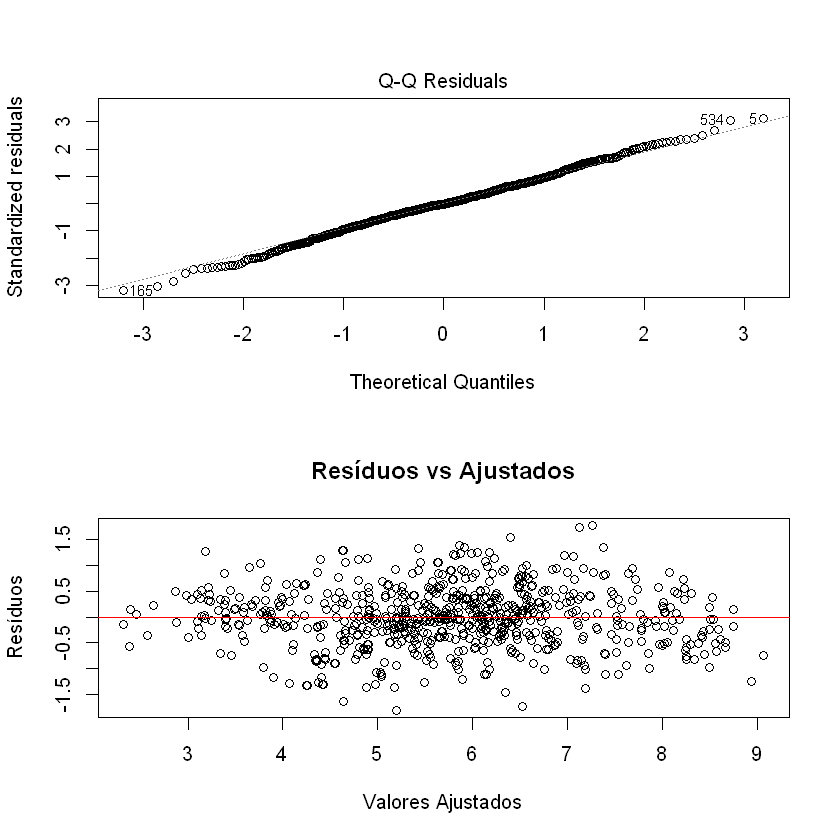

In [9]:
library(lmtest)
residuos <- residuals(modL_step)
ajustados <- fitted(modL_step)

par(mfrow = c(2, 1))

plot(modL_step, which = 2)
plot(ajustados, residuos,
     xlab = "Valores Ajustados", ylab = "Resíduos",
     main = "Resíduos vs Ajustados")
abline(h = 0, col = "red")

par(mfrow = c(1, 1))

[1] 4

5 165 289 534 
  5 165 289 534

Possíveis outliers (resíduo studentizado > |3|): 5 165 289 534 
# A tibble: 4 × 9
  Cimento Escoria CinzaVolante  Agua Superplastificante AgregadoGraudo
    <dbl>   <dbl>        <dbl> <dbl>              <dbl>          <dbl>
1    315      137            0  145                 5.9          1130 
2    382        0            0  186                 0            1111 
3    363.     189            0  165.               11.6           945.
4    451        0            0  165                11.2          1030 
# ℹ 3 more variables: AgregadoMiudo <dbl>, Idade <dbl>, Resistencia <dbl>


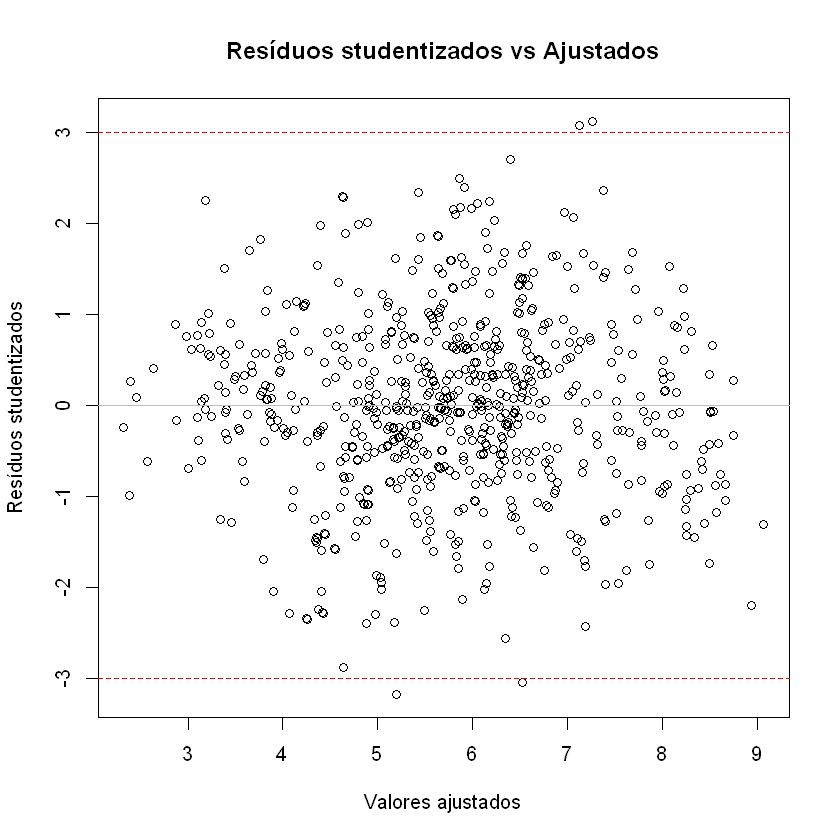

In [10]:
res_std <- rstandard(modL_step)
outliers_idx <- which(abs(res_std) > 3)
length(outliers_idx)
# Índices dos outliers:
outliers_idx

outliers_idx <- which(abs(res_std) > 3)
if(length(outliers_idx) > 0) {
  cat("Possíveis outliers (resíduo studentizado > |3|):", outliers_idx, "\n")
  print(dados_treino[outliers_idx, ])
} else {
  cat("Nenhum outlier grave detectado.\n")
}

plot(fitted(modL_step), res_std,
     xlab = "Valores ajustados", ylab = "Resíduos studentizados",
     main = "Resíduos studentizados vs Ajustados")
abline(h = c(-3, 0, 3), lty = c(2,1,2), col = c("red","gray","red"))

[1] 38

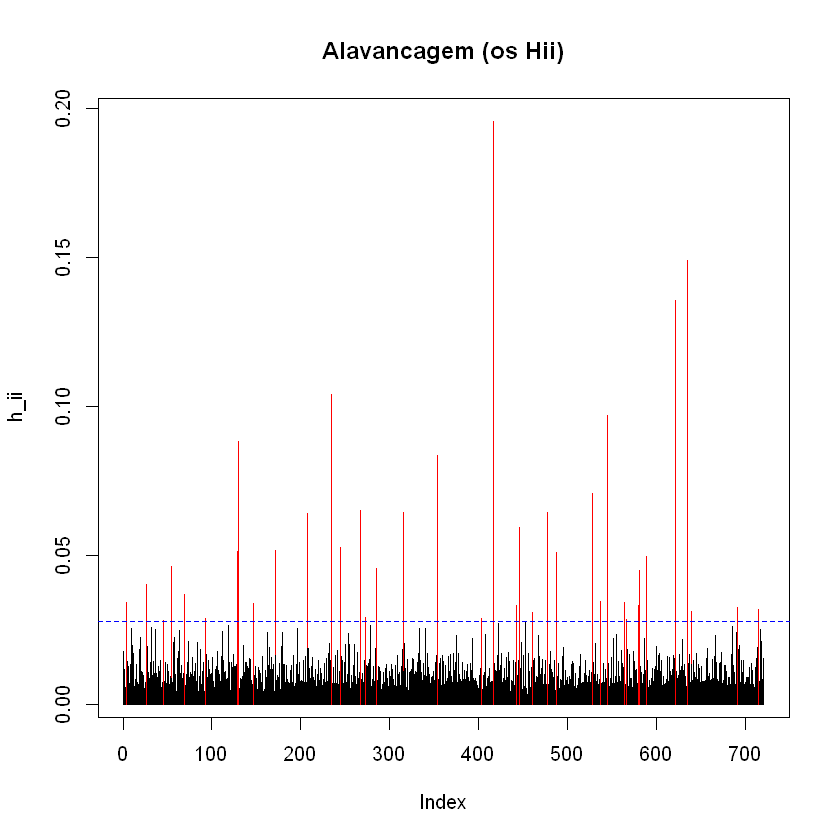

In [53]:
h <- hatvalues(modL_step)
limiar_h <- 2 * length(coef(modL_step)) / nrow(treino)   # 2p/n
plot(h, type = "h", col = ifelse(h > limiar_h, "red", "black"),
     main = "Alavancagem (os Hii)", ylab = "h_ii")
abline(h = limiar_h, lty = 2, col = "blue")

sum(h > limiar_h)

[1] 0.935064

[1] 0

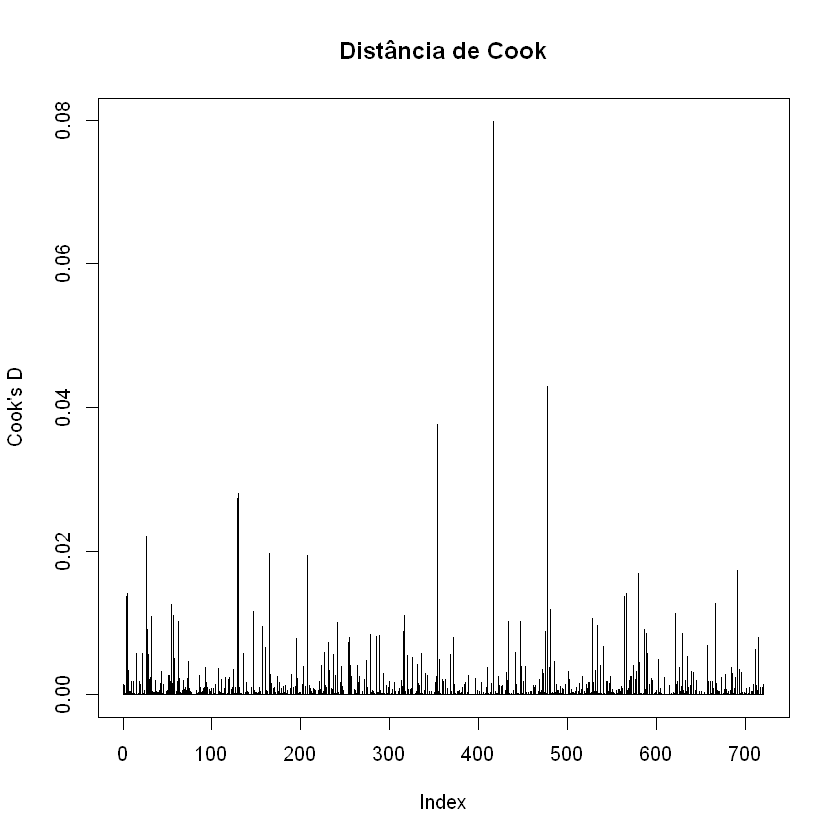

In [49]:
n <- nrow(treino)
p <- length(coef(modL_step))

#D-COOK

#se eu remover essa observação, o modelo inteiro muda muito?
# mede influência global.
cooks_d <- cooks.distance(modL_step)
cook_limite_formal <- qf(0.5, df1 = p, df2 = n - p)
cook_influentes_formais <- which(cooks_d > cook_limite_formal)

# Limite de Cook Formal 
round(cook_limite_formal, 6)

# Número de pontos influentes 
length(cook_influentes_formais)

# Nenhuma observação apresentou distância de Cook acima do limite formal,
# sugerindo ausência de pontos altamente influentes no ajuste global
# da regressão.

# grafico
plot(cooks_d, type = "h", col = ifelse(cooks_d > cook_limite_formal, "red", "black"),
     main = "Distância de Cook", ylab = "Cook's D")
abline(h = cook_limite_formal, lty = 2, col = "blue")

[1] 2

[1] 0

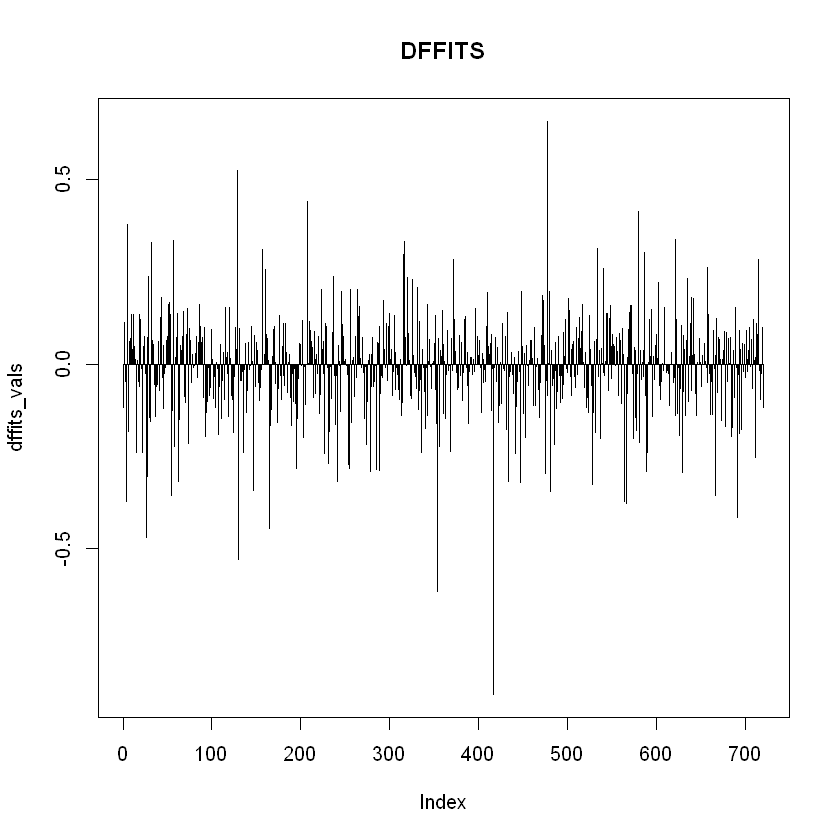

In [54]:
#mede impacto no fitted
dffits_vals <- dffits(modL_step)
dffits_limite <- 2  # amostras grandes

abs_dffits <- abs(dffits_vals)
n_dffits <- sum(abs_dffits > dffits_limite)
round(dffits_limite, 4)
n_dffits

plot(dffits_vals, type = "h", col = ifelse(abs(dffits_vals) > dffits_limite, "red", "black"),
     main = "DFFITS")
abline(h = c(-dffits_limite, dffits_limite), lty = 2, col = "blue")
# Nenhuma observação apresentou DFFITS acima do limite adotado,
# indicando ausência de pontos com forte impacto nas predições do modelo.

In [55]:
# DETECÇÃO DE PONTOS INFLUENTES

#DFBETAS
#essa observação altera muito algum coeficiente β?
dfbetas_vals <- dfbetas(modL_step)
dfbetas_limite <- 2/sqrt(n)  

n_dfbetas_total <- sum(rowSums(abs(dfbetas_vals) > dfbetas_limite) > 0)
round(dfbetas_limite, 4)
n_dfbetas_total

# O critério DFBETAS identificou 143 observações potencialmente
# influentes nos coeficientes.
#o limite 2/sqrt(n) torna-se bastante sensível em
# amostras grandes, resultando na detecção de pequenas alterações
# locais nos coeficientes.
#o limite ficou 0.0745, qualquer observação que altere um coeficiente em mais de 
#0.074 desvios padrão será marcada, muito sensivel.


# Testando com o critério alternativo ∣DFBETAS∣>1
# essa observação altera o coeficiente em mais de 1 erro padrão?
# critério complementar mais conservador.
dfbetas_limite2 <- 1  
n_dfbetas_total2 <- sum(rowSums(abs(dfbetas_vals) > dfbetas_limite2) > 0)
round(dfbetas_limite2, 4)
n_dfbetas_total2
# Nenhuma observação apresentou DFBETAS acima do limite adotado, nenhuma
#altera o coeficiente em mais de 1 erro padrao


[1] 0.0745

[1] 128

[1] 1

[1] 0

In [56]:
summary(modL_step)


Call:
lm(formula = sqrtResist ~ Cimento + Escoria + CinzaVolante + 
    Agua + Idade + AgregadoGraudo + AgregadoMiudo + logIdade + 
    CimXIdade, data = treino)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.80721 -0.34670 -0.01011  0.36603  1.77594 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)    -4.772e+00  1.712e+00  -2.787  0.00546 ** 
Cimento         1.291e-02  5.902e-04  21.868  < 2e-16 ***
Escoria         9.906e-03  6.780e-04  14.610  < 2e-16 ***
CinzaVolante    8.940e-03  8.469e-04  10.556  < 2e-16 ***
Agua           -1.026e-02  2.333e-03  -4.395 1.27e-05 ***
Idade           2.548e-03  1.310e-03   1.945  0.05214 .  
AgregadoGraudo  2.572e-03  5.908e-04   4.353 1.54e-05 ***
AgregadoMiudo   2.941e-03  7.281e-04   4.039 5.94e-05 ***
logIdade        9.325e-01  2.932e-02  31.805  < 2e-16 ***
CimXIdade      -1.968e-05  3.661e-06  -5.376 1.03e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual sta

In [57]:
anova_tipo3 <- Anova(modL_step, type = "III")
print(anova_tipo3)

Anova Table (Type III tests)

Response: sqrtResist
               Sum Sq  Df   F value    Pr(>F)    
(Intercept)      2.55   1    7.7696  0.005455 ** 
Cimento        157.24   1  478.1913 < 2.2e-16 ***
Escoria         70.19   1  213.4475 < 2.2e-16 ***
CinzaVolante    36.64   1  111.4254 < 2.2e-16 ***
Agua             6.35   1   19.3203 1.274e-05 ***
Idade            1.24   1    3.7841  0.052136 .  
AgregadoGraudo   6.23   1   18.9523 1.537e-05 ***
AgregadoMiudo    5.37   1   16.3161 5.944e-05 ***
logIdade       332.64   1 1011.5843 < 2.2e-16 ***
CimXIdade        9.51   1   28.9065 1.031e-07 ***
Residuals      233.80 711                        
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [59]:
predicoes_trans<- predict(modL_step, newdata = validacao)
predicoes <- predicoes_trans^2
validacao$Pred_Resistencia <- predicoes

print(validacao[,c("Resistencia","Pred_Resistencia")], n = 15)

# A tibble: 309 × 2
   Resistencia Pred_Resistencia
         <dbl>            <dbl>
 1       41.1              46.0
 2       44.3              50.1
 3       47.0              33.3
 4       45.9              23.5
 5       43.0              44.3
 6       47.8              24.4
 7       56.1              36.3
 8       40.6              44.0
 9        8.06             10.4
10       44.2              49.1
11       38.6              24.3
12       41.7              44.6
13       42.1              42.9
14       53.7              44.3
15       37.7              43.2
# ℹ 294 more rows


In [ ]:
# erros
erro_teste <- validacao$Resistencia - validacao$Pred_Resistencia

# RMSE
RMSE_teste <- sqrt(mean(erro_teste^2))

# MAE
mae_teste <- mean(abs(erro_teste))

#MAPE
mape <- mean(abs(erro_teste) / validacao$Resistencia)

# R² preditivo (correlação ao quadrado)
r2_pred <- cor(validacao$Resistencia, validacao$Pred_Resistencia)^2

# Exibir resultados
cat("RMSE_teste:", round(RMSE_teste, 4), "\n",
    "MAE_teste:", round(mae_teste, 4), "\n",
    "MAPE:", round(mape,4), "\n",
    "R² preditivo:", round(r2_pred, 4), "\n")

predicoes_treino_trans <- predict(modL_step, newdata = treino)

predicoes_treino <- predicoes_treino_trans^2

treino$Pred_Resistencia <- predicoes_treino
# erros
erro_treino <- treino$Resistencia - treino$Pred_Resistencia

# RMSE
rmse_treino <- sqrt(mean(erro_treino^2))

# MAE
mae_treino <- mean(abs(erro_treino))

# Exibir resultados
cat("RMSE_treino:", round(rmse_treino, 4), "\n",
    "MAE_treino:", round(mae_treino, 4), "\n")

RMSE_teste: 6.8695 
 MAE_teste: 5.1585 
 MAPE: 0.1601 
 R² preditivo: 0.8213 


RMSE_treino: 6.8803 
 MAE_treino: 5.1922 


In [67]:
coef(modL_step)

(Intercept)        Cimento        Escoria   CinzaVolante           Agua 
  -4.771932565    0.012905381    0.009906040    0.008939695   -0.010255212 
         Idade AgregadoGraudo  AgregadoMiudo       logIdade      CimXIdade 
   0.002547868    0.002572045    0.002940842    0.932486754   -0.000019683

In [68]:
dados_brutos <- preparar(dados_brutos)
modelo_final <- lm(sqrtResist ~ Cimento + Escoria + CinzaVolante + Agua + 
           + Idade + AgregadoGraudo + AgregadoMiudo + 
          logIdade + CimXIdade,
          data = dados_brutos )
coef(modelo_final)

(Intercept)        Cimento        Escoria   CinzaVolante           Agua 
 -3.299319e+00   1.230481e-02   9.285294e-03   8.144896e-03  -1.127200e-02 
         Idade AgregadoGraudo  AgregadoMiudo       logIdade      CimXIdade 
  2.454707e-03   2.074049e-03   2.256914e-03   9.339087e-01  -1.989876e-05